In [1]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Switch dataset here: "CICIDS" or "UNSW"
DATASET = "UNSW"

2026-03-13 15:31:56.918515: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 15:31:56.932052: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 15:31:57.394099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 15:31:58.750077: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
if DATASET == "CICIDS":
    file_path = "./combine.csv"
    data = pd.read_csv(file_path)
elif DATASET == "UNSW":
    unsw_files = [
        "./UNSW-NB15_1.csv",
        "./UNSW-NB15_2.csv",
        "./UNSW-NB15_3.csv",
        "./UNSW-NB15_4.csv",
    ]
    unsw_columns = [
        "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes",
        "sttl", "dttl", "sloss", "dloss", "service", "Sload", "Dload", "Spkts", "Dpkts",
        "swin", "dwin", "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len",
        "Sjit", "Djit", "Stime", "Ltime", "Sintpkt", "Dintpkt", "tcprtt", "synack", "ackdat",
        "is_sm_ips_ports", "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd",
        "ct_srv_src", "ct_srv_dst", "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm",
        "ct_dst_sport_ltm", "ct_dst_src_ltm", "attack_cat", "Label"
    ]
    frames = [pd.read_csv(f, header=None, names=unsw_columns, low_memory=False) for f in unsw_files]
    data = pd.concat(frames, ignore_index=True)
else:
    raise ValueError("DATASET must be 'CICIDS' or 'UNSW'")

# Optional memory protection for very large runs:
# data = data.sample(frac=0.5, random_state=42)

In [3]:
data.columns = data.columns.str.strip()

In [4]:
if DATASET == "CICIDS":
    columns_to_drop = [
        'Unnamed: 0', 'Flow ID', 'Source IP', 'Destination IP',
        'Timestamp', 'Source Port', 'Destination Port', 'Protocol'
    ]
    data.drop(columns=columns_to_drop, inplace=True, errors='ignore')
elif DATASET == "UNSW":
    # Remove high-cardinality/raw text identifiers for UNSW.
    data.drop(columns=['srcip', 'dstip', 'attack_cat'], inplace=True, errors='ignore')

In [5]:
print(data['Label'].value_counts(dropna=False).head(15))

Label
0    2218764
1     321283
Name: count, dtype: int64


In [6]:
if DATASET == "CICIDS":
    data['Label'] = data['Label'].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)
elif DATASET == "UNSW":
    # UNSW Label is already binary; enforce numeric 0/1.
    data['Label'] = pd.to_numeric(data['Label'], errors='coerce').fillna(0).astype(int)
    data['Label'] = data['Label'].apply(lambda x: 1 if x == 1 else 0)

In [7]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

if DATASET == "UNSW":
    # Encode required categorical UNSW columns.
    for col in ['proto', 'service', 'state']:
        if col in data.columns:
            data[col] = data[col].fillna('missing').astype(str)
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])

# Fill numeric NaNs only
numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

In [8]:
print("Dataset shape after preprocessing:", data.shape)
print(data.head())

Dataset shape after preprocessing: (2540047, 46)
   sport dsport  proto  state       dur  sbytes  dbytes  sttl  dttl  sloss  \
0   1390     53    120      2  0.001055     132     164    31    29      0   
1  33661   1024    120      2  0.036133     528     304    31    29      0   
2   1464     53    120      2  0.001119     146     178    31    29      0   
3   3593     53    120      2  0.001209     132     164    31    29      0   
4  49664     53    120      2  0.001169     146     178    31    29      0   

   ...  is_ftp_login  ct_ftp_cmd  ct_srv_src  ct_srv_dst  ct_dst_ltm  \
0  ...           0.0           0           3           7           1   
1  ...           0.0           0           2           4           2   
2  ...           0.0           0          12           8           1   
3  ...           0.0           0           6           9           1   
4  ...           0.0           0           7           9           1   

   ct_src_ltm  ct_src_dport_ltm  ct_dst_sport_ltm

In [9]:
# Correlation-based feature removal is intentionally performed after train/test split
# in the scaling/splitting cell to avoid data leakage.
print('Correlation filtering will be applied on X_train_raw only (post-split).')

Correlation filtering will be applied on X_train_raw only (post-split).


In [10]:
X = data.drop(columns=['Label'])
y = data['Label']

In [11]:
print(data['Label'].value_counts())

Label
0    2218764
1     321283
Name: count, dtype: int64


In [12]:
# Split first to prevent data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Drop non-numeric columns (e.g. sport/dsport hex strings in UNSW)
non_numeric_cols = X_train_raw.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print(f"Dropping non-numeric columns: {non_numeric_cols}")
    X_train_raw = X_train_raw.drop(columns=non_numeric_cols)
    X_test_raw  = X_test_raw.drop(columns=non_numeric_cols)

# Correlation filtering only on training features (no leakage)
corr_train = X_train_raw.corr()
upper_triangle = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(abs(upper_triangle[column]) > 0.9)]

X_train_raw = X_train_raw.drop(columns=to_drop, errors='ignore')
X_test_raw = X_test_raw.drop(columns=to_drop, errors='ignore')
print(f"Dropped {len(to_drop)} highly correlated features using training data only.")

# Scale using only training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Save scaler artifact
joblib.dump(scaler, 'scaler.joblib')
print("Scaler saved as 'scaler.joblib'")


Dropping non-numeric columns: ['sport', 'dsport', 'ct_ftp_cmd']
Dropped 13 highly correlated features using training data only.
Scaler saved as 'scaler.joblib'


In [13]:
# Train autoencoder only on benign training traffic
X_train_benign = X_train_scaled[y_train.values == 0]

# Benign train/validation split for autoencoder
X_train_benign, X_val_benign = train_test_split(
    X_train_benign, test_size=0.25, random_state=42
)

# Keep untouched test split (contains both classes)
X_test = X_test_scaled

In [14]:
input_dim = X_train_benign.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(30, activation='relu', kernel_regularizer=l2(0.001))(input_layer)
encoded = Dense(10, activation='relu', kernel_regularizer=l2(0.001))(encoded)
encoded = Dense(5, activation='relu', kernel_regularizer=l2(0.001))(encoded)
decoded = Dense(15, activation='relu', kernel_regularizer=l2(0.001))(encoded)
decoded = Dense(30, activation='relu', kernel_regularizer=l2(0.001))(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Compile Autoencoder
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=1e-5), loss='mean_squared_error')

E0000 00:00:1773396141.661103   19765 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773396141.666877   19765 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_benign, X_train_benign,
    epochs=100,
    batch_size=1024,
    validation_data=(X_val_benign, X_val_benign),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9434 - val_loss: 1.0146
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9246 - val_loss: 0.9937
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9007 - val_loss: 0.9666
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8714 - val_loss: 0.9366
Epoch 5/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8409 - val_loss: 0.9057
Epoch 6/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8085 - val_loss: 0.8715
Epoch 7/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7734 - val_loss: 0.8361
Epoch 8/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7384 - val_loss: 0.8019
Epoch 9/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7030 - val_loss: 0.7654
Epoch 10/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6668 - val_loss: 0.7305
Epoch 11/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6341 - val_loss: 0.6998
Epoch 12/100
1219/1

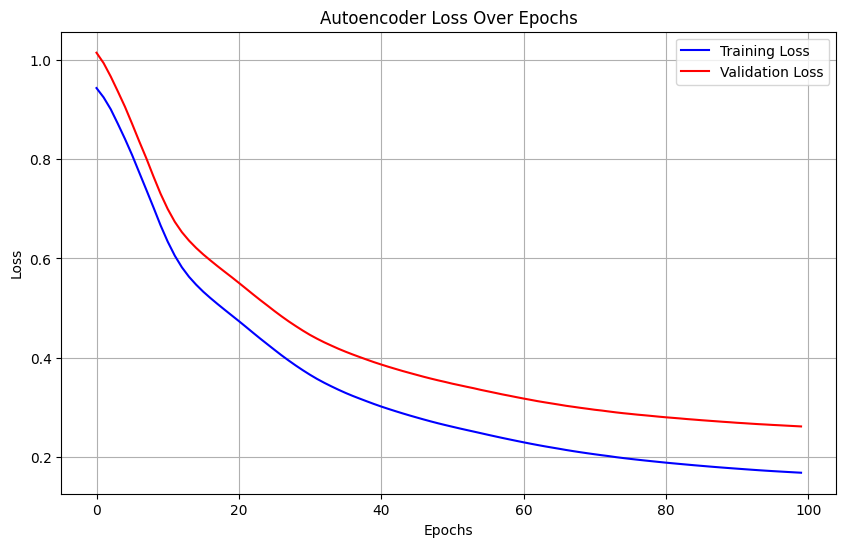

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Autoencoder Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [17]:
autoencoder.save('autoencoder_xg_model.h5')
print("Autoencoder model saved as 'autoencoder_xg_model.h5'")


Autoencoder model saved as 'autoencoder_xg_model.h5'


In [18]:
encoder_model = Model(inputs=autoencoder.input, outputs=encoded)
encoder_model.save('encoder_model.h5')
print("Encoder model saved as 'encoder_model.h5'")

X_train_encoded = encoder_model.predict(X_train_scaled)
X_test_encoded = encoder_model.predict(X_test_scaled)

Encoder model saved as 'encoder_model.h5'
59533/59533 ━━━━━━━━━━━━━━━━━━━━ 18s 294us/step
19845/19845 ━━━━━━━━━━━━━━━━━━━━ 6s 292us/step


In [19]:
# Apply SMOTE only to training encoded features
smote = SMOTE(random_state=42)
X_train_encoded_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

print("Training class distribution before SMOTE:")
print(y_train.value_counts())
print("\nTraining class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Training class distribution before SMOTE:
Label
0    1664073
1     240962
Name: count, dtype: int64

Training class distribution after SMOTE:
Label
0    1664073
1    1664073
Name: count, dtype: int64


In [20]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_encoded_smote, y_train_smote)

# Save XGBoost model
joblib.dump(xgb_model, 'xgb_model.joblib')
print("XGBoost model saved as 'xgb_model.joblib'")

XGBoost model saved as 'xgb_model.joblib'



--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    554691
           1       0.85      1.00      0.92     80321

    accuracy                           0.98    635012
   macro avg       0.92      0.98      0.95    635012
weighted avg       0.98      0.98      0.98    635012



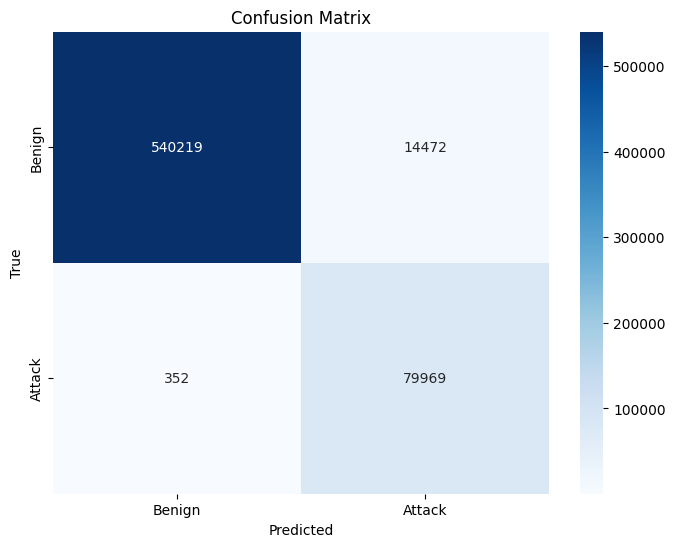

In [21]:
y_pred = xgb_model.predict(X_test_encoded)
y_pred_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


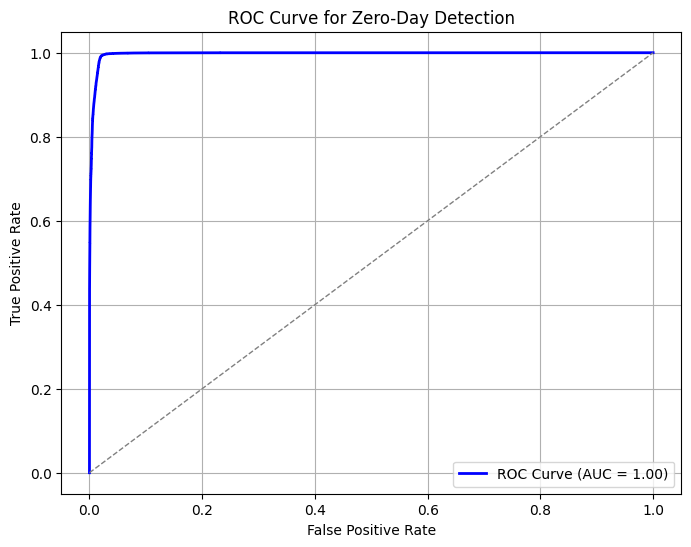

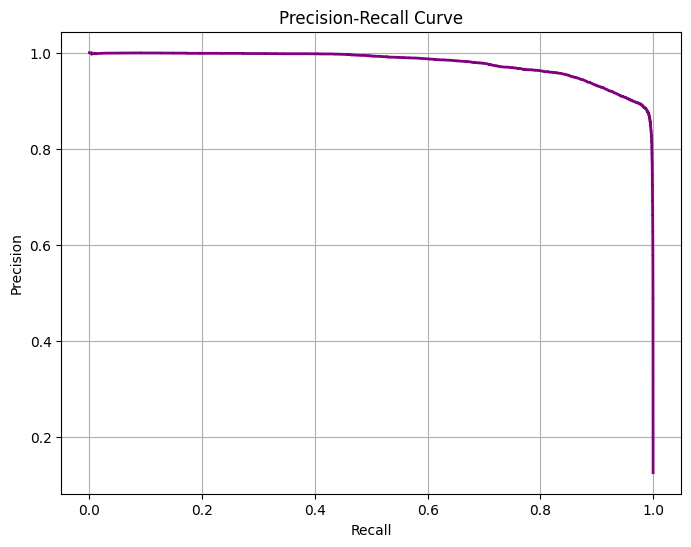

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('ROC Curve for Zero-Day Detection')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Precision-Recall curve (important for imbalanced datasets)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

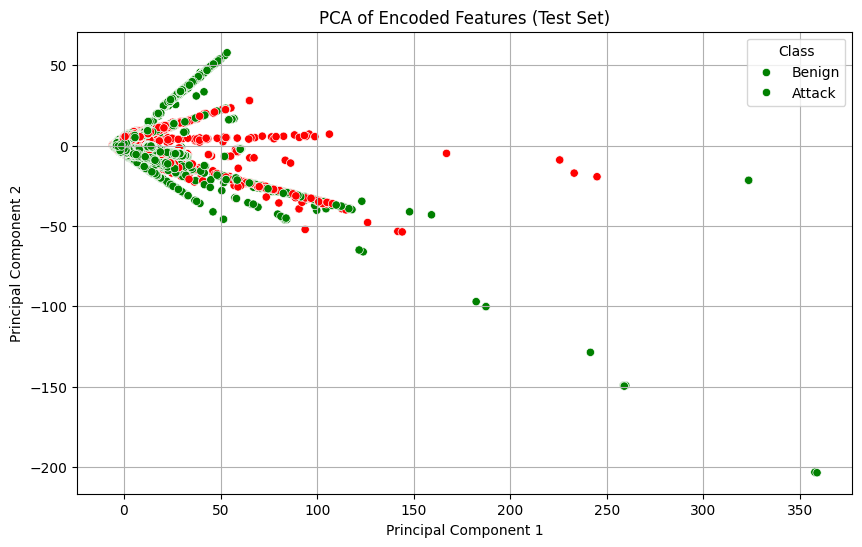

In [23]:
# PCA for Encoded Features
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
encoded_features_pca = pca.fit_transform(X_test_encoded)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=encoded_features_pca[:, 0], y=encoded_features_pca[:, 1],
    hue=y_test, palette={0: 'green', 1: 'red'}, legend='full'
)
plt.title('PCA of Encoded Features (Test Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class', labels=['Benign', 'Attack'])
plt.grid()
plt.show()

In [24]:
# Compute reconstruction-error threshold from benign training data
recon_train_benign = autoencoder.predict(X_train_benign)
benign_train_errors = np.mean(np.square(recon_train_benign - X_train_benign), axis=1)
threshold = np.percentile(benign_train_errors, 95)

# Compute reconstruction errors on the untouched test set
reconstructions = autoencoder.predict(X_test_scaled)
reconstruction_errors = np.mean(np.square(reconstructions - X_test_scaled), axis=1)

reconstruction_df = pd.DataFrame({
    'ReconstructionError': reconstruction_errors,
    'Label': y_test.values
})

print(f"Anomaly threshold (95th percentile of benign train error): {threshold:.6f}")

39002/39002 ━━━━━━━━━━━━━━━━━━━━ 13s 331us/step
19845/19845 ━━━━━━━━━━━━━━━━━━━━ 7s 331us/step
Anomaly threshold (95th percentile of benign train error): 0.298069


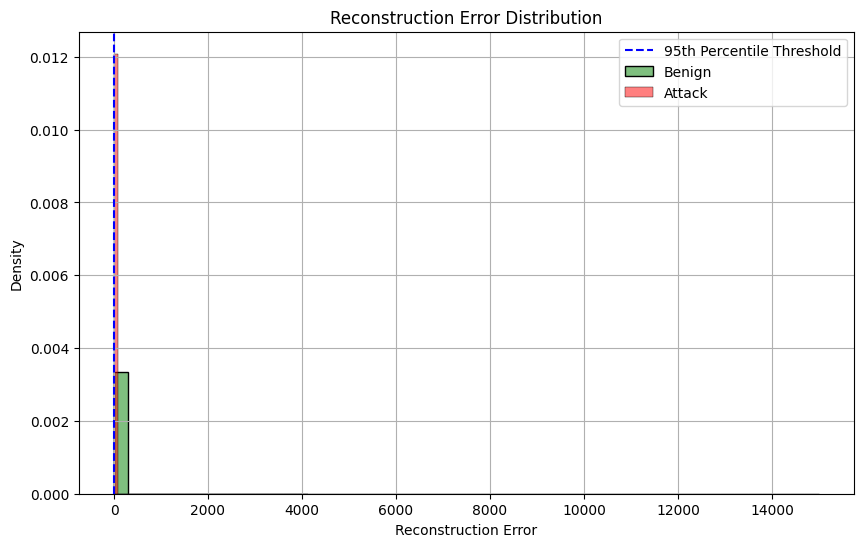

In [25]:
# Plot Reconstruction Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(reconstruction_df['ReconstructionError'][reconstruction_df['Label'] == 0], bins=50, color='green', label='Benign', stat='density', alpha=0.5)
sns.histplot(reconstruction_df['ReconstructionError'][reconstruction_df['Label'] == 1], bins=50, color='red', label='Attack', stat='density', alpha=0.5)
plt.axvline(x=threshold, color='blue', linestyle='--', label='95th Percentile Threshold')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

In [26]:
required_vars = ['xgb_model', 'X_train_encoded', 'X_test_encoded', 'y_train', 'y_test']

if all(var in globals() for var in required_vars):
    # Compatibility aliases for downstream Random Forest-named cells
    rf_classifier = xgb_model
    X_train_rf, X_test_rf = X_train_encoded, X_test_encoded
    y_train_rf, y_test_rf = y_train, y_test
    print(X_test_rf.shape[1])
else:
    print('Run the notebook training cells up to XGBoost fitting before this step.')

5


In [27]:
print('Synthetic dataset generation using make_classification has been removed to keep evaluation realistic.')

Synthetic dataset generation using make_classification has been removed to keep evaluation realistic.


In [28]:
print('Synthetic data analysis cell disabled because synthetic test generation is removed.')

Synthetic data analysis cell disabled because synthetic test generation is removed.


In [29]:
print('SMOTE on test data is disabled. SMOTE is applied only on training data before XGBoost training.')

SMOTE on test data is disabled. SMOTE is applied only on training data before XGBoost training.


SMOTE Class Distribution (Training Set):
Benign: 1664073, Attack: 1664073


/tmp/ipykernel_19765/271729230.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Benign', 'Attack'], y=smote_class_distribution, palette='coolwarm')


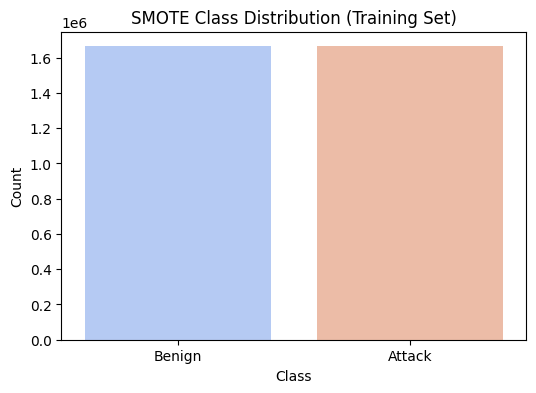

In [30]:
required_vars = ['X_train_encoded_smote', 'y_train_smote']

if all(var in globals() for var in required_vars):
    # Class distribution after training-only SMOTE
    smote_class_distribution = np.bincount(y_train_smote)

    print("SMOTE Class Distribution (Training Set):")
    print(f"Benign: {smote_class_distribution[0]}, Attack: {smote_class_distribution[1]}")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=['Benign', 'Attack'], y=smote_class_distribution, palette='coolwarm')
    plt.title('SMOTE Class Distribution (Training Set)')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()
else:
    print('Run SMOTE training cell before this step.')